# 11. Runge-Kutta method, Version 1

Can we do better than Euler's rule? https://www.youtube.com/watch?v=v-pbGAts_Fg

For our projectile example, we always see an overshoot, and that's because we've been using time derivatives (e.g. the slope $dz/dt$) estimated from the starting end of each timestep. Any better ways to estimate? Taking the average of two endpoints is one way. Here we'll introduce a method to make a more educated guess of the time derivative at the halfway point of every time step.

(Sketch out Euler's rule versus plans for Runge-Kutta's method on board).

Overall plan: implement Runge-Kutta  plan out three versions.

- v1, full version with explicit details, compare errors and O(dt^2)
- v2, shorter version with d/dt function separated out
- v3, even shorter version with vectorization, using numpy arrays.

A recap of the expected errors of Euler's method and the Runge-Kutta method at 2nd order:

**Euler**: local error $O(dt^2)$, global error $O(dt)$

**RK2**:   local error $O(dt^3)$, global error $O(dt^2)$


<div class="span alert alert-info">

## A pause for reflection

**Q:** Why are we going into details of all these ODE solvers? Why can't we use ODE solvers readily available in scipy? see e.g. [scipy.solve_ivp documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html)

**A #1. Practial skills.** The usage of available functions in any module requires some technical understanding of the underlying method. For example, if you look at the usage of  solve_ivp, you see arguments like 
solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, dense_output=False, events=None, vectorized=False, args=None, **options)
What's "fun", and "y0", and all the other options? These are the things we'll pick up along the way in explaining the details. Of course we won't have time to dissect every function in numpy and scipy, but we hope that through this example of dissecting an ODE solver, you can see that there are always these inner workings of a function that you can learn about with reference books and studies, in conjunction with reading code documentations.

**A #2. Analytical skills and computational mindset**. Going through these details also help us establish a mindset of doing computational physics simulations. Coming up with a characteristic timescale or lengthscale, choosing a timestep, understanding how error behaves as a consequence of your choice of algorithm, compartmentalizing your code – these are all skills we pick up along the way that are generally applicable to any physical problem!
    
    
-
</div>


## Projectile motion with air drag
For this project, we'll look at projectile motion considering air drag. Let's start from a clean slate where Euler's method is implemented.

In [1]:
b= 0.3 # in units of /s

def move(zpos,zvel, xpos, xvel):
    zpos += zvel* dt
    zvel = zvel + (-g-b*zvel) * dt
    xpos += xvel *dt
    xvel = xvel + (-b*xvel) *dt    
    return zpos, zvel, xpos, xvel

Here we've introduced air drag where force $= -b_1 \times$ velocity, so acceleration = $-b_1 /$ mass $\times$ velocity  $ \equiv b \times$ velocity. 

Here $b_1$ and $b$ are constant proportionality factors, assuming linear air drag.

# Runge-Kutta method, at 2nd order

The basic idea of the Runge-Kutta method is to use a better slope to get from one timestep to the next.

In Euler's method we've seen that, for our projectile example, using the slope $dz/dt$ at the starting point of every timestep would result in the particle overshooting. Likewise, if we take the slope $dz/dt$ at the end point of every timestep, that would be too small. At natual solution is to use the midpoint. 

For the example, zpos = zpos + zvel_half * dt. Here zvel_half is not the velocity $dz/dt$ at time $t$ or $t+dt$, but at $t+dt/2$.



Let's begin with a clean slate. Below is a minimal piece of script where Euler's method is already implemented. We'll choose a short time step for this Euler's method solution, so that it serves as a reference (close enough to a perfect solution) when we later compare with the Runge-Kutta method solution.

For simplicity we'll remove the bouncing feature for now and only focus on the first arc of the trajectory.

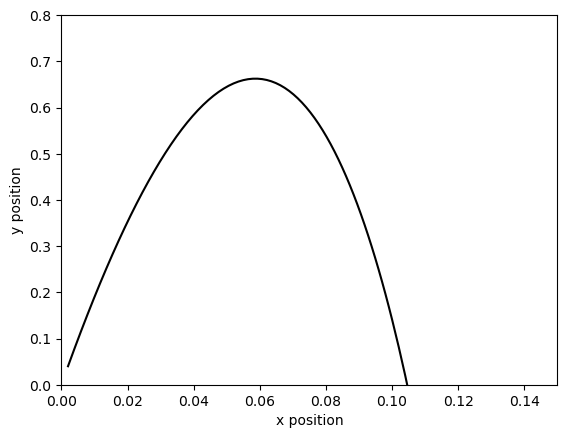

In [4]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.01 # in seconds
t_range = np.arange(0,2,dt)

g = 9.8
mass = 2.0
b = 1  # /s

def move(dt, xpos, xvel, zpos, zvel):
    xpos = xpos + xvel * dt
    zpos = zpos + zvel * dt
    zvel = zvel + (-g-b*zvel) * dt
    xvel = xvel + (-b*xvel) *dt
    return xpos, xvel, zpos, zvel

#initialize particle state
xpos=0
xvel=0.2
zpos=0
zvel=4.0
xn=[]
zn=[]

for t in t_range:
    xpos, xvel, zpos, zvel = move(dt, xpos, xvel, zpos, zvel)
    xn.append(xpos)
    zn.append(zpos)

fig, ax = plt.subplots(1)
ax.plot(xn,zn,'k-')
ax.set_xlim(0,0.15)
ax.set_ylim(0,0.8)
ax.set_ylabel('y position')
ax.set_xlabel('x position')
plt.show()

Now we'll implement the Runge-Kutta method at 2nd order. It's easier to work backwards, starting from what we need at the end: update every variable by their time derivative taken at the midpoint between t and t+dt.

In [3]:
    # At the end (at t + dt)
    xpos = xpos + xvel_half * dt
    xvel = xvel + xacc_half * dt
    zpos = zpos + zvel_half * dt
    zvel = zvel + zacc_half * dt

NameError: name 'xvel_half' is not defined

Now we need to calulate these time derivatives. All the accelerations are calculated at the same instant in time, whereas all the velocities are propogated from time t by dt/2

In [ ]:
    # In the middle (at t+dt/2)
    xvel_half = xvel + xacc * dt/2
    xacc_half = -b * xvel_half
    zvel_half = zvel + zacc * dt/2
    zacc_half = -g -b * zvel_half

And finally, at the very beginning, we need to calculate the accelerations at time t

In [ ]:
    # At the start (at time t)
    xacc = -b * xvel
    zacc = -g - b*zvel

Putting everything together, our code now looks like the following.

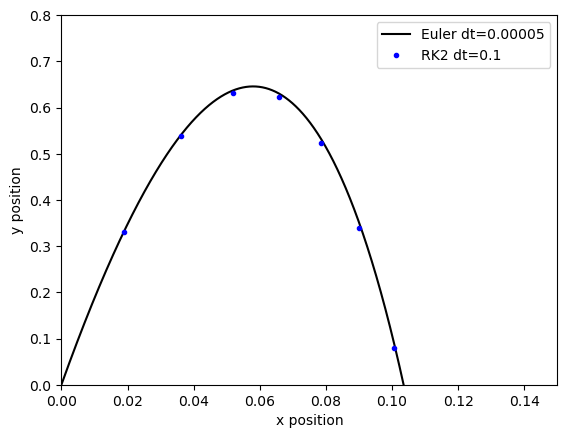

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
dt = 0.00005 # in seconds
t_range = np.arange(0,2,dt)

g = 9.8
mass = 10
b = 1  # /s

def move_Euler(xpos, xvel, zpos, zvel):
    xpos = xpos + xvel * dt
    zpos = zpos + zvel * dt
    zvel = zvel + (-g-b*zvel) * dt
    xvel = xvel + (-b*xvel) *dt
    return xpos, xvel, zpos, zvel

def move_RK2( xpos, xvel, zpos, zvel):
    xacc = -b * xvel
    zacc = -g - b*zvel
    
    xvel_half = xvel + xacc * dt/2
    xacc_half = -b * xvel_half
    zvel_half = zvel + zacc * dt/2
    zacc_half = -g -b * zvel_half
    
    xpos = xpos + xvel_half * dt
    xvel = xvel + xacc_half * dt
    zpos = zpos + zvel_half * dt
    zvel = zvel + zacc_half * dt
    return xpos, xvel, zpos, zvel

#initialize particle state
xpos=0
xvel=0.2
zpos=0
zvel=4.0
xn=[]
zn=[]
for t in t_range:
    xpos, xvel, zpos, zvel = move_Euler(xpos, xvel, zpos, zvel)
    xn.append(xpos)
    zn.append(zpos)
    
#initialize particle state
dt = 0.1
xpos=0
xvel=0.2
zpos=0
zvel=4.0
xr=[]
zr=[]
for t in t_range:
    xpos, xvel, zpos, zvel = move_RK2(xpos, xvel, zpos, zvel)
    xr.append(xpos)
    zr.append(zpos)
#plotting numerical
fig, ax = plt.subplots(1)
ax.plot(xn,zn,'k-')
ax.plot(xr,zr,'b.')
ax.set_xlim(0,0.15)
ax.set_ylim(0,0.8)
ax.set_ylabel('y position')
ax.set_xlabel('x position')
ax.legend(['Euler dt=0.00005','RK2 dt=0.1'])

Notice that the RK2 method solution (blue dots) is very accurate even though the timestep is HUGE ($dt=0.1$ seconds)! This demonstrates the much smaller error of the Runge-Kutta 2nd order method.

Demonstration of $O(dt^2)$ global error behavior:

At dt = 0.1 s,  error = 0.090-0.078 = 0.012m
At dt = 0.05 s,  error = 0.088-0.085 = 0.003m



This concludes version 1 of our RK2 code to simulate projectile motion.